## PCA implementation

In [2]:
class MyPCA:
    
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        
    def fit(self, X):
        
        # Step 1: Mean center data
        X_meaned = X - np.mean(X, axis=0)
        
        # Step 2: Covariance matrix
        cov_matrix = np.cov(X_meaned, rowvar=False)
        
        # Step 3: Eigen decomposition
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
        
        # Step 4: Sort eigenvectors
        idxs = np.argsort(eigenvalues)[::-1]
        eigenvectors = eigenvectors[:, idxs]
        
        self.components = eigenvectors[:, :self.n_components]
        
    def transform(self, X):
        X_meaned = X - np.mean(X, axis=0)
        return np.real(X_meaned @ self.components)

## 3d Data

In [11]:
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=1000,
    n_features=3,
    n_informative = 3,
    n_redundant=0,
    n_classes=2,
    n_clusters_per_class=2,
    class_sep=1.8,
    flip_y=0.01)

import pandas as pd

df = pd.DataFrame(X, columns=["Feature1", "Feature2", "Feature3"])
df["Class"] = y.astype(str)

fig = px.scatter_3d(df,
                    x="Feature1",
                    y="Feature2",
                    z="Feature3",
                    color="Class",
                    title="Original 3D Data")

fig.show()

# 2️⃣ Standardize (IMPORTANT!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
pca = MyPCA(n_components=2)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

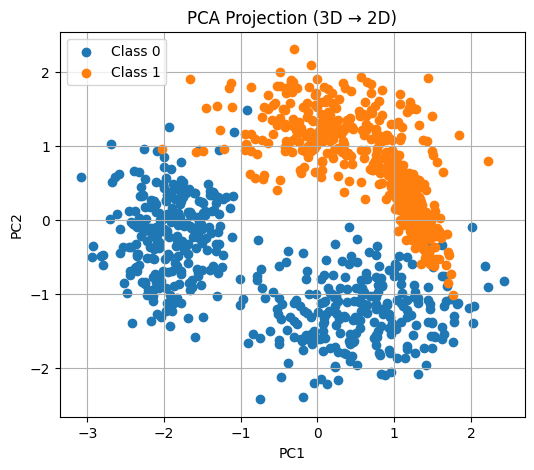

In [13]:
plt.figure(figsize=(6,5))

for label in np.unique(y):
    plt.scatter(X_pca[y==label, 0],
                # np.zeros_like(X_pca[y==label,0]), 
                
                X_pca[y==label, 1],
                label=f"Class {label}")

plt.title("PCA Projection (3D → 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()